# 07 - LSTM tok treniranja kroz epohe

Ova sveska prati kako se LSTM model menja tokom 20 epoha. Na trening i validacionom skupu merimo gresku, a na validacionom skupu dodatno pratimo F1 meru za spam klasu. Test skup se ne koristi.

In [7]:
from pathlib import Path
import os

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".matplotlib_cache"))
os.environ.setdefault("XDG_CACHE_HOME", str(ROOT / ".cache"))

print(f"Sveska je pokrenuta. Direktorijum projekta: {ROOT}")


Sveska je pokrenuta. Direktorijum projekta: /Users/markoraskovic/Desktop/ML projekat


## Ucitavanje biblioteka

In [8]:
from collections import Counter
import re

import matplotlib.pyplot as plt
import pandas as pd
import torch
from sklearn.metrics import f1_score
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import DataLoader, TensorDataset

print("Biblioteke su uspesno ucitane.")

Biblioteke su uspesno ucitane.


## Podaci i izabrani hiperparametri

Koristimo konfiguraciju koja je u prethodnoj svesci dala najbolji validacioni F1: recnik od 5000 reci, embedding dimenzije 64 i LSTM stanje dimenzije 64.

In [9]:
TRAIN_PATH = ROOT / "data" / "processed" / "splits" / "train.csv"
VALIDATION_PATH = ROOT / "data" / "processed" / "splits" / "validation.csv"
MAX_WORDS = 5000
MAX_LEN = 50
BATCH_SIZE = 64
EMBEDDING_DIM = 64
LSTM_DIM = 64
LEARNING_RATE = 0.001
DROPOUT = 0.2
EPOCHS = 20

torch.manual_seed(42)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

train_df = pd.read_csv(TRAIN_PATH)
validation_df = pd.read_csv(VALIDATION_PATH)
print(f"Uredjaj za treniranje: {device}")
print(f"Trening: {len(train_df)}, validacija: {len(validation_df)}")

Uredjaj za treniranje: mps
Trening: 2013, validacija: 431


## Pretvaranje teksta u brojeve i LSTM model

In [10]:
def tokenize(text):
    return re.findall(r"[a-z]+(?:'[a-z]+)?", str(text).lower())


word_counter = Counter()
for message in train_df["message"]:
    word_counter.update(tokenize(message))

vocab = {"<PAD>": 0, "<UNK>": 1}
for word, _ in word_counter.most_common(MAX_WORDS - 2):
    vocab[word] = len(vocab)


def encode_message(message):
    numbers = [vocab.get(token, vocab["<UNK>"]) for token in tokenize(message)][:MAX_LEN]
    length = max(1, len(numbers))
    numbers += [vocab["<PAD>"]] * (MAX_LEN - len(numbers))
    return numbers, length


def make_dataset(df):
    encoded = [encode_message(message) for message in df["message"]]
    x = torch.tensor([message for message, _ in encoded], dtype=torch.long)
    lengths = torch.tensor([length for _, length in encoded], dtype=torch.long)
    y = torch.tensor([1 if label == "spam" else 0 for label in df["label"]], dtype=torch.float32)
    return TensorDataset(x, lengths, y)


class LSTMClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(len(vocab), EMBEDDING_DIM, padding_idx=0)
        self.lstm = nn.LSTM(EMBEDDING_DIM, LSTM_DIM, batch_first=True)
        self.dropout = nn.Dropout(DROPOUT)
        self.linear = nn.Linear(LSTM_DIM, 1)

    def forward(self, x, lengths):
        x = self.embedding(x)
        x = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(x)
        return self.linear(self.dropout(hidden[-1])).squeeze(1)

## Treniranje i cuvanje istorije

Posle svake epohe racunamo prosecan trening loss, prosecan validacioni loss i F1 za spam. Manji loss je bolji, dok je veci F1 bolji.

In [11]:
train_dataset = make_dataset(train_df)
validation_dataset = make_dataset(validation_df)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE)

model = LSTMClassifier().to(device)
spam_count = (train_df["label"] == "spam").sum()
ham_count = (train_df["label"] == "ham").sum()
pos_weight = torch.tensor([ham_count / spam_count], dtype=torch.float32, device=device)
loss_function = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss_sum = 0.0

    for x_batch, lengths, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(x_batch, lengths)
        loss = loss_function(logits, y_batch)
        loss.backward()
        optimizer.step()
        train_loss_sum += loss.item() * len(y_batch)

    model.eval()
    validation_loss_sum = 0.0
    real_labels = []
    predicted_labels = []

    with torch.no_grad():
        for x_batch, lengths, y_batch in validation_loader:
            x_batch, y_device = x_batch.to(device), y_batch.to(device)
            logits = model(x_batch, lengths)
            loss = loss_function(logits, y_device)
            validation_loss_sum += loss.item() * len(y_batch)
            predictions = (torch.sigmoid(logits) >= 0.5).int().cpu().tolist()
            real_labels.extend(y_batch.int().tolist())
            predicted_labels.extend(predictions)

    train_loss = train_loss_sum / len(train_dataset)
    validation_loss = validation_loss_sum / len(validation_dataset)
    validation_f1 = f1_score(real_labels, predicted_labels, pos_label=1, zero_division=0)
    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "validation_loss": validation_loss,
        "validation_spam_f1": validation_f1,
    })
    print(
        f"Epoha {epoch:02d}/{EPOCHS}: "
        f"train loss={train_loss:.4f}, validation loss={validation_loss:.4f}, "
        f"spam F1={validation_f1:.4f}"
    )

history_df = pd.DataFrame(history)
history_df

Epoha 01/20: train loss=1.1413, validation loss=1.1253, spam F1=0.3488
Epoha 02/20: train loss=1.0251, validation loss=0.7947, spam F1=0.6044
Epoha 03/20: train loss=0.6226, validation loss=0.4624, spam F1=0.8050
Epoha 04/20: train loss=0.4051, validation loss=0.3218, spam F1=0.8844
Epoha 05/20: train loss=0.2804, validation loss=0.2880, spam F1=0.8844
Epoha 06/20: train loss=0.2105, validation loss=0.3371, spam F1=0.8905
Epoha 07/20: train loss=0.1592, validation loss=0.2887, spam F1=0.9343
Epoha 08/20: train loss=0.1319, validation loss=0.3824, spam F1=0.9254
Epoha 09/20: train loss=0.1089, validation loss=0.2564, spam F1=0.9353
Epoha 10/20: train loss=0.0827, validation loss=0.2325, spam F1=0.9362
Epoha 11/20: train loss=0.0546, validation loss=0.3068, spam F1=0.9489
Epoha 12/20: train loss=0.0439, validation loss=0.3074, spam F1=0.9489
Epoha 13/20: train loss=0.0346, validation loss=0.2596, spam F1=0.9420
Epoha 14/20: train loss=0.0227, validation loss=0.2989, spam F1=0.9559
Epoha 

,epoch,train_loss,validation_loss,validation_spam_f1
0,1,1.141308,1.125261,0.348837
1,2,1.025076,0.794652,0.604396
2,3,0.622623,0.462439,0.805031
3,4,0.405053,0.321818,0.884354
4,5,0.280378,0.288034,0.884354
5,6,0.210490,0.337068,0.890511
6,7,0.159218,0.288681,0.934307
7,8,0.131873,0.382393,0.925373
8,9,0.108863,0.256405,0.935252
9,10,0.082669,0.232516,0.936170


## Linijski grafikoni

Levi grafik prikazuje gresku. Ako trening greska opada, a validaciona pocne da raste, to je znak preprilagodjavanja. Desni grafik prikazuje koliko dobro model prepoznaje spam posle svake epohe.

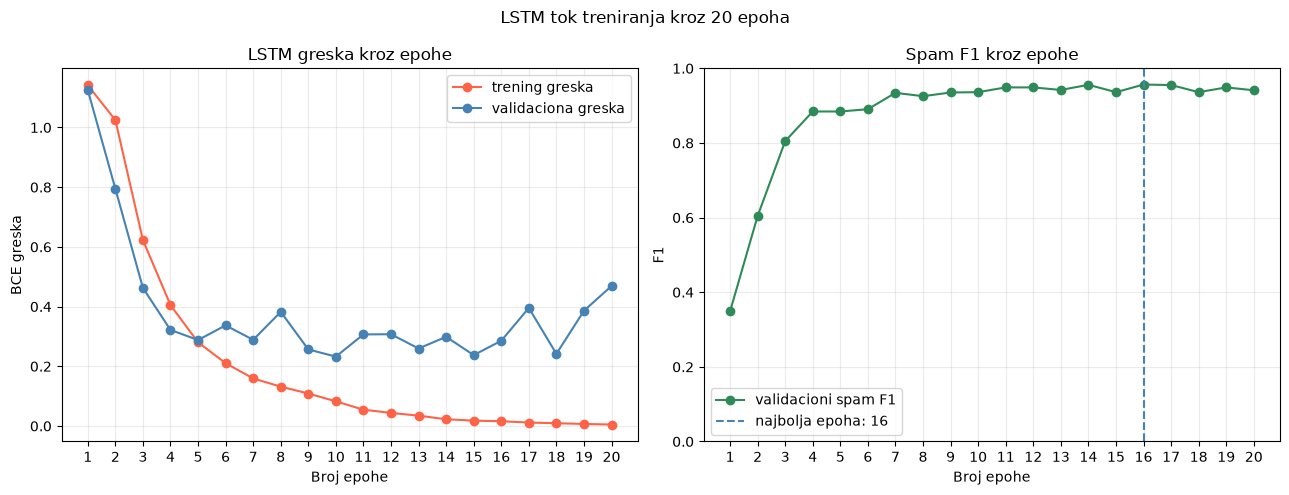

Najveci validacioni spam F1 je u epohi 16.


In [12]:
best_epoch = int(history_df.loc[history_df["validation_spam_f1"].idxmax(), "epoch"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", color="tomato", label="trening greska")
axes[0].plot(history_df["epoch"], history_df["validation_loss"], marker="o", color="steelblue", label="validaciona greska")
axes[0].set_title("LSTM greska kroz epohe")
axes[0].set_xlabel("Broj epohe")
axes[0].set_ylabel("BCE greska")
axes[0].set_xticks(range(1, EPOCHS + 1))
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["validation_spam_f1"], marker="o", color="seagreen", label="validacioni spam F1")
axes[1].axvline(best_epoch, color="steelblue", linestyle="--", label=f"najbolja epoha: {best_epoch}")
axes[1].set_title("Spam F1 kroz epohe")
axes[1].set_xlabel("Broj epohe")
axes[1].set_ylabel("F1")
axes[1].set_xticks(range(1, EPOCHS + 1))
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.25)
axes[1].legend()

fig.suptitle("LSTM tok treniranja kroz 20 epoha")
plt.tight_layout()

plt.show()

print(f"Najveci validacioni spam F1 je u epohi {best_epoch}.")

## Tumacenje

Za izbor broja epoha nije dovoljno gledati samo trening gresku. Najkorisnija je epoha u kojoj validacioni F1 dostize maksimum, dok validaciona greska jos nije pocela znacajno da raste.